In [1]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [2]:
penguins = sns.load_dataset('penguins')

In [5]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [4]:
# 1 - Nesse exercício vocês devem verificar se temos variáveis missing, faltantes e excluir esses valores do dataset, 
# também devem excluir as colunas com valores categóricos, que não utilizazam para o Kmeans.

In [6]:
penguins.isnull().values.any() #Indica que existe(m) valor(es) nulo(s) no dataframe

True

In [7]:
penguins.isnull().sum() # numero de valores nulos por coluna

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [8]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [9]:
# Excluindo (bill_length_mm)

penguins.dropna(subset=['bill_length_mm'], inplace=True)

# Excluindo (bill_depth_mm)

penguins.dropna(subset=['bill_depth_mm'], inplace=True)

# Excluindo (body_mass_g)

penguins.dropna(subset=['body_mass_g'], inplace=True)

# Excluindo (sex)

penguins.dropna(subset=['sex'], inplace=True)

In [10]:
penguins.isnull().sum() # numero de valores nulos por coluna

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [11]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.8+ KB


In [13]:
# Excluindo colunas com valores categóricos

penguins.drop(columns=['species', 'island', 'sex'], inplace=True)

In [14]:
penguins

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0
...,...,...,...,...
338,47.2,13.7,214.0,4925.0
340,46.8,14.3,215.0,4850.0
341,50.4,15.7,222.0,5750.0
342,45.2,14.8,212.0,5200.0


In [15]:
# 2 - Visualize a análise descritiva dos seus dados utilizando a função vista em aula pairplot. É possível já identificar possíveis agrupamentos? 
# Se sim, quantos?

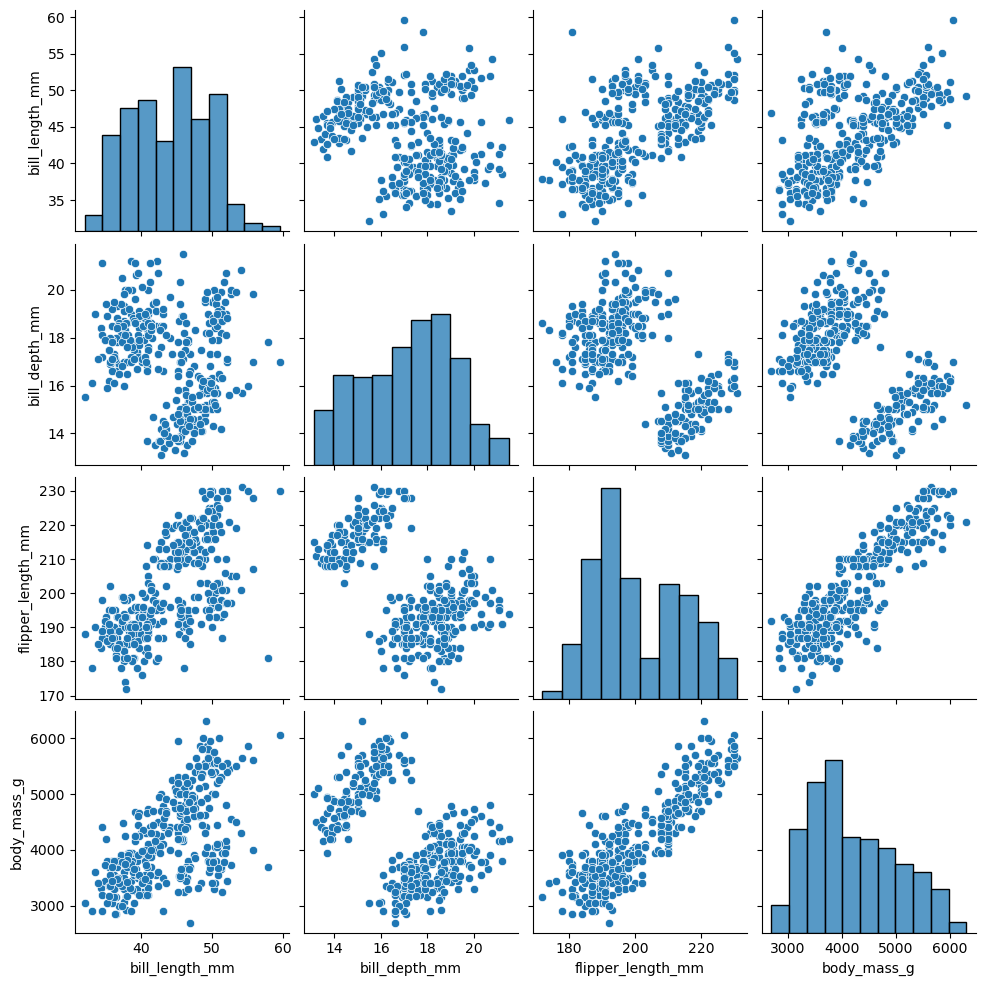

In [16]:
sns.pairplot(penguins)

In [17]:
# em bill_length_mm é possivel visualizar 3 agrupamentos

# em bill_depth_mm é possivel ver 3 agrupamentos no primeiro grafico, porem nao tao dispersos, e 2 agrupamentos nos graficos seguintes

# em flipper_length_mm o primeiro grafico esta se dispersando em 3 clusters; o segundo está em 2 e o terceiro esta se dividindo em 2, porem com pontos ainda 
# bem proximos

# body_mass_g o primeiro grafico esta se dividindo em 2 clusters; o segundo ja apresentar uma divisao clara entre 2 clusters;
# o terceiro ainda esta fortemente conectado em 1 cluster, porem com sinais de dispersao 

In [18]:
# 3 - Realize a padronização dos dados e visualize os dados.

In [22]:
# Padronizacao (ou normalização) dos dados

penguins_padronizado = penguins.copy()

In [23]:
colunas_padronizar = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Iniciar o StandardScaler
scaler = StandardScaler()

# Ajustar e transformar os dados selecionados
penguins_padronizado[colunas_padronizar] = scaler.fit_transform(penguins[colunas_padronizar])

In [24]:
penguins_padronizado

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,-0.896042,0.780732,-1.426752,-0.568475
1,-0.822788,0.119584,-1.069474,-0.506286
2,-0.676280,0.424729,-0.426373,-1.190361
4,-1.335566,1.085877,-0.569284,-0.941606
5,-0.859415,1.747026,-0.783651,-0.692852
...,...,...,...,...
338,0.587352,-1.762145,0.931283,0.892957
340,0.514098,-1.457000,1.002739,0.799674
341,1.173384,-0.744994,1.502928,1.919069
342,0.221082,-1.202712,0.788372,1.234995


In [19]:
# 4 - Aplique o algoritmo do k means escolhendo o numero de clusters como igual a 3, que é que a quantidade de espécies que temos na base.

In [25]:
kmeans_especie = KMeans (n_clusters=3, n_init=10, random_state=42)
kmeans_especie.fit(penguins_padronizado)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [20]:
# 5 - Construa pelo 2 matriz de dispersão como realizada em aula indicando os pontos e centroides.

# **Comece usando x='bill_length_mm' e y='bill_depth_mm' para analisar o primeiro gráfico e em seguida escolha outras variaveis para o segundo.**

In [26]:
centroides_padronizado = kmeans_especie.cluster_centers_
centroides_originais = scaler.inverse_transform(centroides_padronizado)
centroides_originais

array([[  38.27674419,   18.12170543,  188.62790698, 3593.79844961],
       [  47.56806723,   14.99663866,  217.23529412, 5092.43697479],
       [  47.66235294,   18.74823529,  196.91764706, 3898.23529412]])

In [27]:
labels = kmeans_especie.labels_
labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0,
       0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0,
       0, 2, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2,
       0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

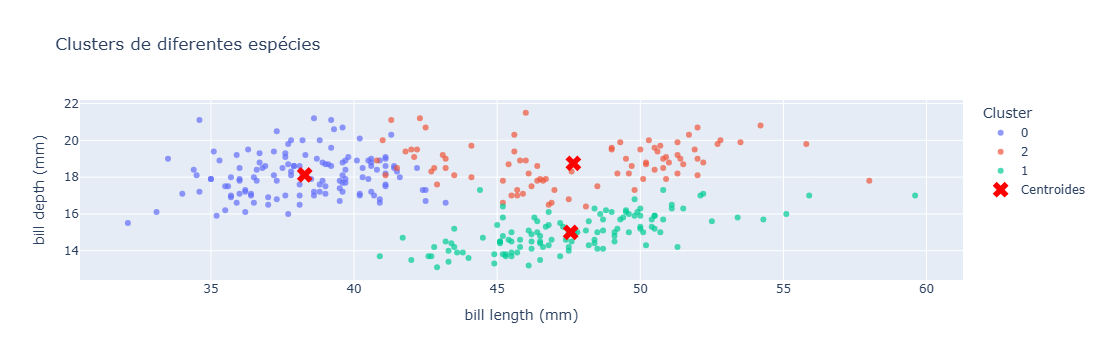

In [29]:
df_clusters = pd.DataFrame({
	'bill_length_mm':penguins['bill_length_mm'],
	'bill_depth_mm': penguins['bill_depth_mm'],
	'cluster': labels.astype(str)
})

fig = px.scatter(df_clusters, x='bill_length_mm', y='bill_depth_mm', color='cluster',
		color_continuous_scale='viridis', opacity=0.7,
		title='Clusters de diferentes espécies')

fig.add_scatter(x=centroides_originais[:, 0], y=centroides_originais[:, 1],
		mode='markers', marker=dict(color='red', symbol='x', size=14),
		name='Centroides')

fig.update_layout(xaxis_title='bill length (mm)', yaxis_title='bill depth (mm)',
		legend_title='Cluster')
fig.show()

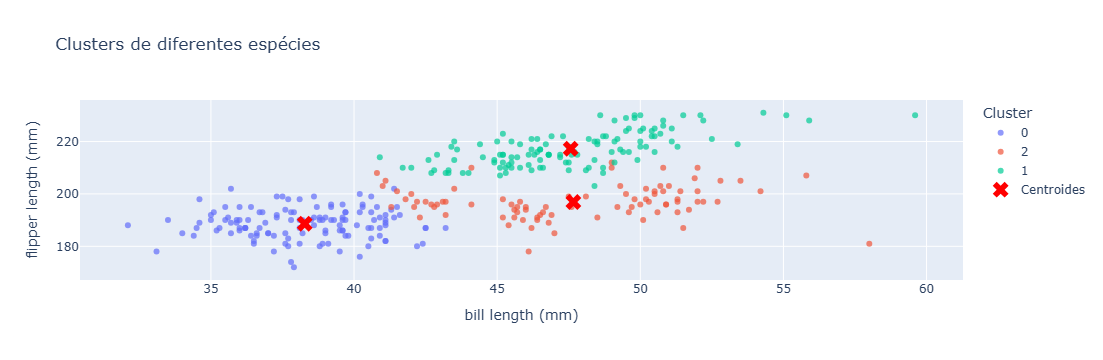

In [33]:
df_clusters = pd.DataFrame({
	'bill_length_mm':penguins['bill_length_mm'],
	'flipper_length_mm': penguins['flipper_length_mm'],
	'cluster': labels.astype(str)
})

fig = px.scatter(df_clusters, x='bill_length_mm', y='flipper_length_mm', color='cluster',
		color_continuous_scale='viridis', opacity=0.7,
		title='Clusters de diferentes espécies')

fig.add_scatter(x=centroides_originais[:, 0], y=centroides_originais[:, 2],
		mode='markers', marker=dict(color='red', symbol='x', size=14),
		name='Centroides')

fig.update_layout(xaxis_title='bill length (mm)', yaxis_title='flipper length (mm)',
		legend_title='Cluster')
fig.show()

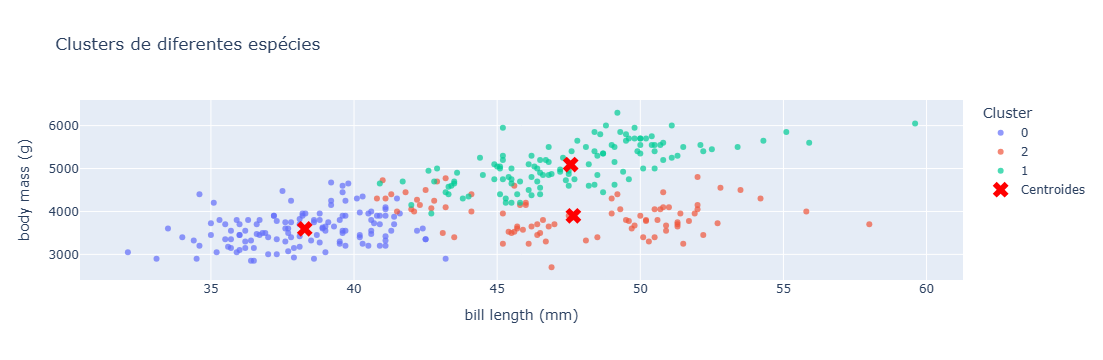

In [34]:
df_clusters = pd.DataFrame({
	'bill_length_mm':penguins['bill_length_mm'],
	'body_mass_g': penguins['body_mass_g'],
	'cluster': labels.astype(str)
})

fig = px.scatter(df_clusters, x='bill_length_mm', y='body_mass_g', color='cluster',
		color_continuous_scale='viridis', opacity=0.7,
		title='Clusters de diferentes espécies')

fig.add_scatter(x=centroides_originais[:, 0], y=centroides_originais[:, 3],
		mode='markers', marker=dict(color='red', symbol='x', size=14),
		name='Centroides')

fig.update_layout(xaxis_title='bill length (mm)', yaxis_title='body mass (g)',
		legend_title='Cluster')
fig.show()

In [21]:
# 6 - Pesquise mais 3 utilidades de aplicações de algoritmos de clusterização e cite abaixo:

In [ ]:
# Segmentação de Clientes: No marketing e vendas, algoritmos de clusterização são amplamente utilizados para segmentar clientes em grupos com 
# características e comportamentos similares. Isso permite que as empresas personalizem campanhas de marketing, ofertas de produtos e abordagens de 
# atendimento ao cliente para cada segmento, aumentando a eficácia e a satisfação do cliente. Por exemplo, uma loja online pode agrupar clientes que 
# compram frequentemente eletrônicos, clientes que preferem roupas e clientes que focam em livros, direcionando promoções específicas para cada grupo.

# Detecção de Anomalias: A clusterização pode ser usada para identificar pontos de dados que não se encaixam em nenhum grupo bem definido, 
# sendo considerados anomalias ou outliers. Em aplicações como detecção de fraudes financeiras, transações que não se agrupam com o comportamento 
# normal dos clientes podem ser sinalizadas para investigação. Da mesma forma, em sistemas de monitoramento de máquinas industriais, leituras de 
# sensores que se desviam dos padrões normais (clusters) podem indicar falhas ou necessidades de manutenção.

# Análise e Agrupamento de Documentos e Textos: No processamento de linguagem natural (PLN), algoritmos de clusterização podem agrupar documentos, 
# artigos de notícias, posts de redes sociais ou outros tipos de texto com base na similaridade de seu conteúdo. Isso facilita a organização de 
# grandes volumes de informação, a descoberta de tópicos emergentes, a criação de sistemas de recomendação de conteúdo e a análise de sentimentos em 
# diferentes grupos de textos. Por exemplo, um sistema de notícias pode agrupar artigos relacionados ao mesmo evento, mesmo que usem palavras diferentes.